# **Section 2: Feature Engineering**

## **Author**
Ophélie Rutschmann

## **Introduction**
This project uses a house price dataset compiled and published by Dean De Cock, which contains 2,930 observations across 82 features. The original data, sourced directly from the Ames Assessor’s Office, was collected for tax assessment purposes.

The primary goal of this project is to develop and evaluate models that can accurately predict house prices based on the available features. This notebook focuses on the second phase of the project: **Feature engineering**.

## **Methods**

The goal of this section is to enhance the dataset by creating new features and transforming existing ones to improve the predictive power of the model. There are several strategies that I will follow during this section, with the goal to capture additional information from the raw data.

Here are some of the strategies that were used during this section:
- Creating new indicator variables for the presence / absence of certain features
- Combining features into a new summary variable (total rooms, total basement, type of porch, etc)
- Creating polynomial variables for features that have a non-linear relationship to sale price

Note that a feature engineering step which consisted of log-transforming continuous features was already performed in the first section, as I chose to do this transformation before performing outlier removal for the continuous features in the data set.

In this notebook, I will perform feature engineering on both the training and test datasets. All transformations and new features will be based on the **training** data, and the same transformations will be applied to the **test** data to ensure consistency and avoid data leakage.

## **Table of content**

This notebook is separated into the following sections:
1. **Creating indicator variables**
    - 1.1 Selecting the variables
    - 1.2 Indicator variables for variables we wish to replace
    - 1.3 Indicator variables for variables we do not wish to replace
2. **Creating summary variables**
    - 2.1 Total Bathrooms
3. **Creating polynomial variables**
    - 3.1 Selecting the variables



## **Academic Integrity and Learning Statement**

By submitting my work, I confirm that:

- The code, analysis, and documentation in this notebook are my own work and reflect my own understanding.
- I am prepared to explain all code and analysis included in this submission.

If I used assistance (e.g., AI tools, tutors, or other resources), I have:

- Clearly documented where and how external tools or resources were used in my solution.
- Included a copy of the interaction (e.g., AI conversation or tutoring notes) in an appendix.

I acknowledge that:

- I may be asked to explain any part of my code or analysis during evaluation.
- Misrepresenting assisted work as my own constitutes academic dishonesty and undermines my learning.


## **1. Creating indicator variables** 

When looking at the continuous variables, we can see that the dataset originally contains many variables with a lot of 0s. This is probably to indicate the absence of the item in the variable, i.e. a house that has a 0 in the wood deck SF variable likely doesn't have a wood deck). One of the options to treat this is to add a binary indicator variable (e.g. hasDeck, hasPool, etc.). In some cases, we can then remove the original variable (we will do this for the pool area variable, as a big percentage of the houses don't have a pool. In this case, the presence or absence of a pool carries more information than the size of the pool). 

In other cases, we can keep both the indicator variable and the original variable, as we can hypothesize that both the presence/absence of the feature and the size of the feature carry predictive power for the model. This is for instance the case for the "Wood Deck" variable.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("clean_df.csv")
data_test = pd.read_csv("clean_df_test.csv")

In [3]:
df = data.copy()
df_test = data_test.copy()

### **1.1. Selecting the variables**
We will start by plotting all of the continuous variables to get a sense of the data set, and what variables we should create indicator variables for.

In [4]:
cont_col = ["Lot Frontage", "Lot Area", "Mas Vnr Area", "BsmtFin SF 1",
            "Total Bsmt SF", "1st Flr SF", "2nd Flr SF", "Gr Liv Area", "Garage Area", 
            "Wood Deck SF", "Open Porch SF", "Enclosed Porch", "3Ssn Porch", "Screen Porch", "Pool Area"]

/home/ruop/miniconda3/envs/adsml/lib/python3.9/site-packages/pandas/plotting/_core.py:1746: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


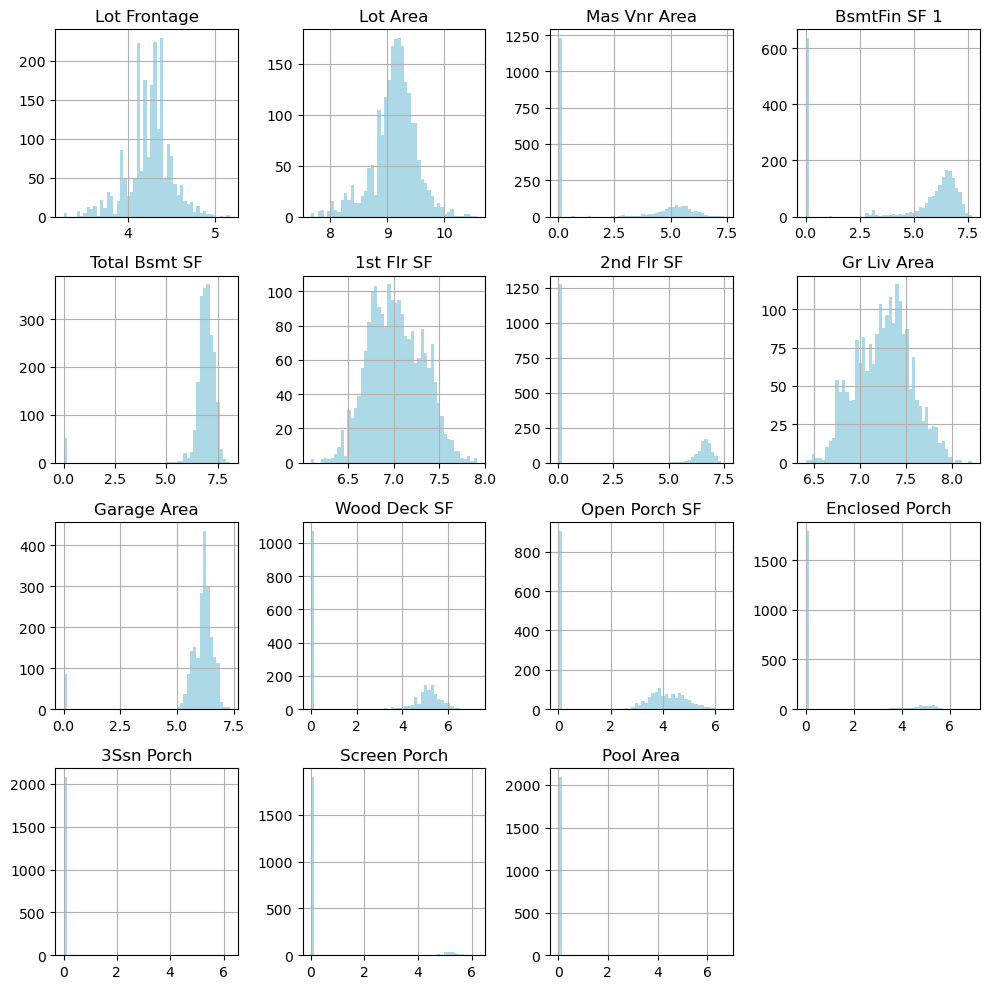

In [5]:
df[cont_col].hist(color="lightblue", bins=50, figsize = (10,10))
plt.tight_layout()
plt.show()

From these plots, we see that the variables with a lot of 0s are:
- Pool Area
- Screen Porch
- 3Ssn Porch
- Enclosed Porch
- Open Porch SF
- Wood Deck SF
- Garage Area
- 2nd Floor SF
- Total Bsmt SF
- BsmtFin SF 1
- Mas Vnr Area

Let's see what their relationship to the sale price is.

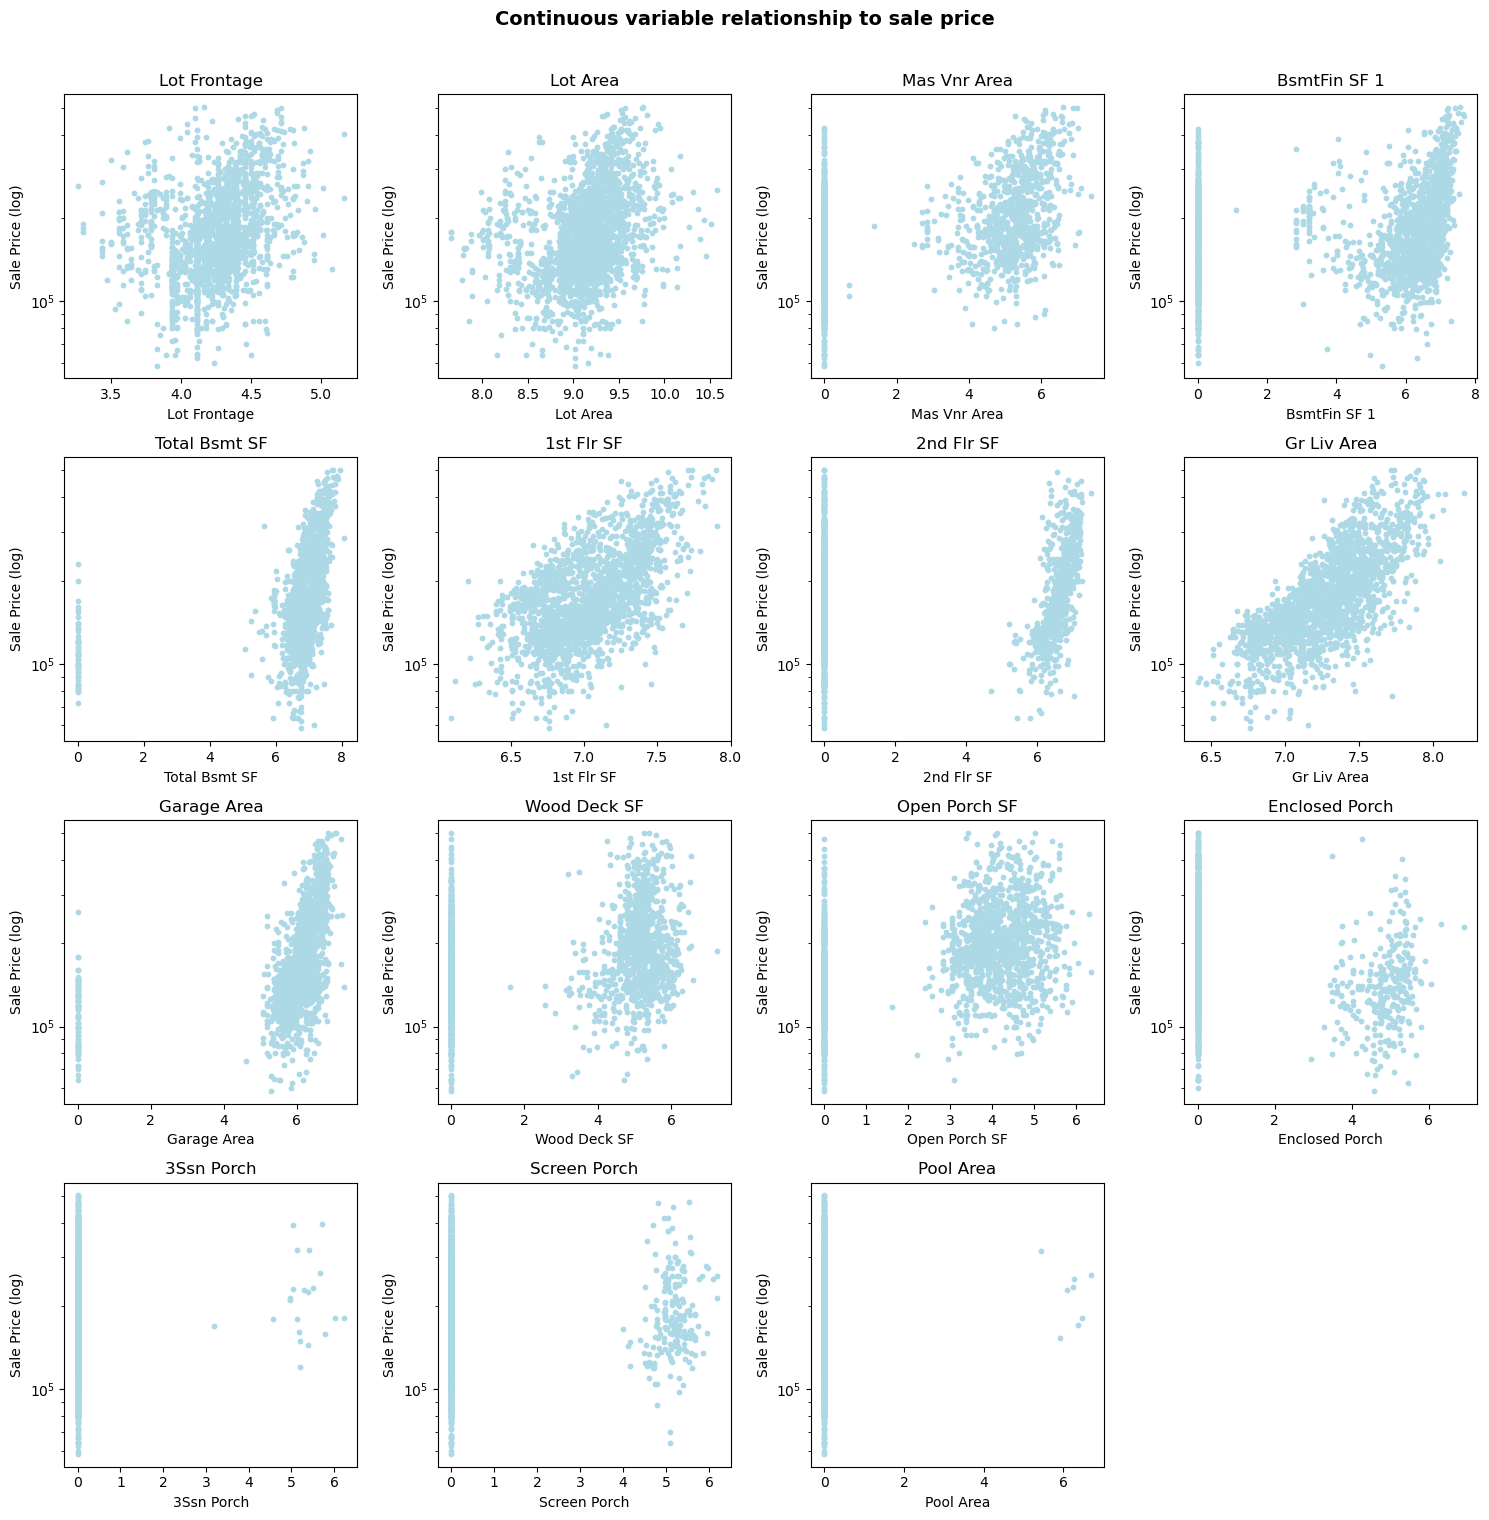

In [6]:
# Scatter plots for the continuous columns 
import math

# compute the number of rows and columns for the subplot
n_cols = 4
n_rows = math.ceil(len(cont_col) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 15))
axes = axes.flatten()

for col, i in zip(cont_col, range(len(cont_col))):
        axes[i].scatter(data[col], data["SalePrice"], s=10, color="lightblue")
        axes[i].set_title(str(col))
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Sale Price (log)")
        axes[i].set_yscale("log")

# Remove unused subplots
for j in range(len(cont_col), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Continuous variable relationship to sale price", fontsize=14, y=1.01, fontweight="bold")
plt.tight_layout()
plt.show()


We observe different cases. For some features (such as Pool Area), the vast majority of the data is equal to 0. In this case, it might make sense to replace the "area" variable with an indicator variable directly. 

For other features, (such as Garage Area or 2nd Floor SF), it is likely that both the surface area and the presence/absence of the feature could be valuable for the model. In this case, we can create an indicator variable **in addition** to the area variable. 

Finally, we also notice that we have four different "Porch" variables. It might make sense to combine these features into a summary variable containing the porch type. We can do this in a later section of this notebook.

### **1.2 Indicator variables for variables we wish to replace**

Several of the features above seem to not contain information in the "area" of the feature they have, but rather in the presence absence of the feature. This is clearly the case for the pool area for instance, and could also be the case for the Porch variables. 

#### **Pool Area Variable**

Let's start by creating a new feature "HasPool" for the Pool Area variable. We can then remove the old "Pool Area" feature as it doesn't contain a lot of information anymore.

In [7]:
df["HasPool"] = (df["Pool Area"] > 0).astype(int)
df = df.drop(["Pool Area"], axis=1)

In [8]:
df_test["HasPool"] = (df_test["Pool Area"] > 0).astype(int)
df_test = df_test.drop(["Pool Area"], axis=1)

#### **Porch variables**
Let's investigate if a lot of information is contained in the "area" part of these features. To do so, we will do a correlation analysis and plot each variable without the 0s in relation to the sale price.

In [9]:
porch_col = ["Screen Porch", "3Ssn Porch", "Enclosed Porch", "Open Porch SF"]

corr_screen = df.loc[(df["Screen Porch"] > 0), ("Screen Porch", "SalePrice")].corr()["SalePrice"].drop("SalePrice")
corr_3Ssn = df.loc[(df["3Ssn Porch"] > 0), ("3Ssn Porch", "SalePrice")].corr()["SalePrice"].drop("SalePrice")
corr_enclosed = df.loc[(df["Enclosed Porch"] > 0), ("Enclosed Porch", "SalePrice")].corr()["SalePrice"].drop("SalePrice")
corr_open = df.loc[(df["Open Porch SF"] > 0), ("Open Porch SF", "SalePrice")].corr()["SalePrice"].drop("SalePrice")


print(corr_screen)
print(corr_3Ssn)
print(corr_enclosed)
print(corr_open)

Screen Porch    0.120188
Name: SalePrice, dtype: float64
3Ssn Porch    0.120799
Name: SalePrice, dtype: float64
Enclosed Porch    0.196577
Name: SalePrice, dtype: float64
Open Porch SF    0.129222
Name: SalePrice, dtype: float64


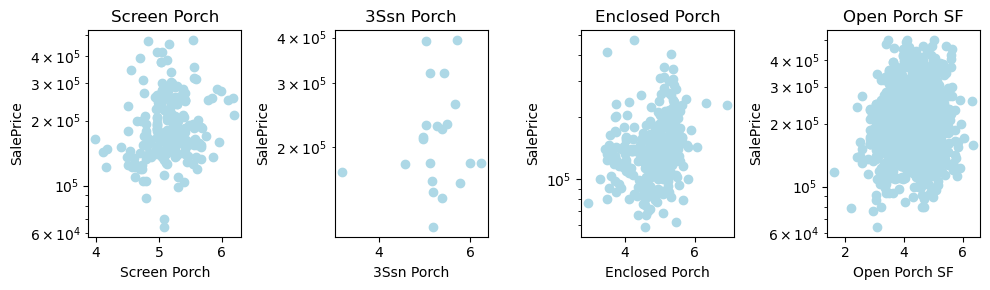

In [10]:
fig, axes = plt.subplots(1, 4, figsize=(10, 3))
axes.flatten()

for col, ax in zip(porch_col, axes):
    ax.scatter(x=df.loc[df[col] > 0, col], y=df.loc[df[col] > 0, "SalePrice"], color="lightblue")
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("SalePrice")
    ax.set_yscale("log")

plt.tight_layout()
plt.show()

We clearly see that there does not seem to be a strong correlation between the sale price and the area of the different porches. Let's thus replace these features with indicator variables. Before completely deleting the original variables, we could try combining them to see if their combination is correlated to the sale price. We can do this in the section "Summary variables" below. 

For now, let's create the indicator variables and keep the porch columns in the data set, knowing that they might need to be combined to carry useful information

In [11]:
df["HasScreenPorch"] = (df["Screen Porch"] > 0).astype(int)
df_test["HasScreenPorch"] = (df_test["Screen Porch"] > 0).astype(int)


In [12]:
df["Has3SsnPorch"] = (df["3Ssn Porch"] > 0).astype(int)
df_test["Has3SsnPorch"] = (df_test["3Ssn Porch"] > 0).astype(int)

In [13]:
df["HasEncloseddPorch"] = (df["Enclosed Porch"] > 0).astype(int)
df_test["HasEnclosedPorch"] = (df_test["Enclosed Porch"] > 0).astype(int)

In [14]:
df["HasOpendPorch"] = (df["Open Porch SF"] > 0).astype(int)
df_test["HasOpenPorch"] = (df_test["Open Porch SF"] > 0).astype(int)

### **1.3 Indicator variables without replacement**
We will now make indicator variables for other continuous variables with a lot of 0s. For these variables, we wish to keep the original variable as the area of the feature seems to have an influence on the sale price. 
The variables we will address are :
- Wood Deck SF
- Garage Area
- 2nd Floor SF
- Mas Vnr Area
- BsmFin SF 1

In [15]:
# Making binary variables for the other variables with a lot of 0s (without replacing them)
df["HasOpenPorch"] = (df["Open Porch SF"] > 0).astype(int)
df["HasWoodDeck"] = (df["Wood Deck SF"] > 0).astype(int)
df["HasGarage"] = (df["Garage Area"] > 0).astype(int)
df["Has2ndFlr"] = (df["2nd Flr SF"] > 0).astype(int)
df["HasMasonry"] = (df["Mas Vnr Area"] > 0).astype(int)
df["HasBsmt"] = (df["BsmtFin SF 1"] > 0).astype(int)

In [16]:
# Making binary variables for the other variables with a lot of 0s (without replacing them)
df_test["HasWoodDeck"] = (df_test["Wood Deck SF"] > 0).astype(int)
df_test["HasGarage"] = (df_test["Garage Area"] > 0).astype(int)
df_test["Has2ndFlr"] = (df_test["2nd Flr SF"] > 0).astype(int)
df_test["HasMasonry"] = (df_test["Mas Vnr Area"] > 0).astype(int)
df_test["HasBsmt"] = (df_test["BsmtFin SF 1"] > 0).astype(int)

## **2. Creating summary variables**

We will now focus on making summary variables to pool the information contained in several variables together. 

We will investigate the following variables:
- Porch variables
- Bathroom variables
- Total surface area

### **2.1 Porch Variables**

Let's see if combining the porch variable into a new "Total Porch" variable would be better for our model.

In [25]:
df["Total Porch"] = df[porch_col].sum(axis=1)

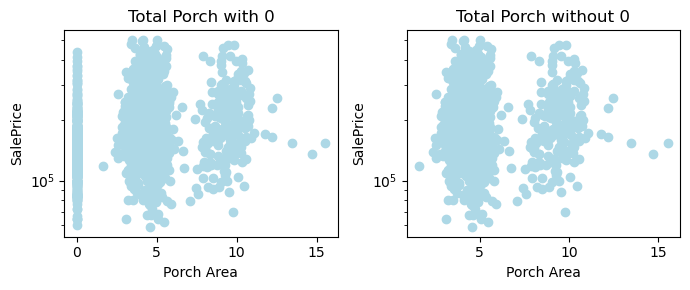

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(7, 3))
axes[0].scatter(x=df["Total Porch"], y=df["SalePrice"], color="lightblue")
axes[0].set_title("Total Porch with 0")
axes[0].set_yscale("log")
axes[0].set_ylabel("SalePrice")
axes[0].set_xlabel("Porch Area")

axes[1].scatter(x=df.loc[df["Total Porch"] > 0, "Total Porch"], y=df.loc[df["Total Porch"] > 0, "SalePrice"], color="lightblue")
axes[1].set_title("Total Porch without 0")
axes[1].set_yscale("log")
axes[1].set_ylabel("SalePrice")
axes[1].set_xlabel("Porch Area")

plt.tight_layout()
plt.show()


Let's also calculate the correlation of this feature with the sale price.

In [29]:
print(df.loc[df["Total Porch"] > 0, ("Total Porch", "SalePrice")].corr()["SalePrice"])

Total Porch    0.029813
SalePrice      1.000000
Name: SalePrice, dtype: float64


Based on the correlation that is very low, and based on the scatter plots, I will take the decision to not use this feature and simply remove the different porch variables. All of the important information is likely already contained in the indicator variables we made above.

In [32]:
df.drop(porch_col, axis=1, inplace=True)
df.drop("Total Porch", axis=1, inplace=True)
df_test.drop(porch_col, axis=1, inplace=True)

### **2.2 Bathroom variables**

During the first section, we already aggregated the above ground bathrooms together as part of our data cleaning strategy. However, several houses contain not only bathrooms above ground, but also bathrooms in the basement. I will now investigate if it would make sense to create a "Total Bathroom" feature that includes the above ground and basement bathrooms together. For this feature, we could multiply the bathrooms in the basement by 0.5 as they probably have less impact on the sale price than the bathrooms above ground. But before taking this decision, let's first visualize the features.